In [50]:
"""
Query-Aware Scalable Softmax (QASSMax) (https://arxiv.org/pdf/2602.11139) is an extension of SSMax by Nakanishi 2025 and 
is a method that sharpens attention distributions by rescaling queries before computing logits
It was introduced by TabICLv2 at inria and is also used in TabPFN v3, which I'm building right now. 
I want to make an experiment replicating figure one of Nakanishis paper that illustrates how it shapers attention distributions by 
the increasing vector size and showing that the probability value for the clear winner degrades with vanilla softmax. 
"""

"\nQuery-Aware Scalable Softmax (QASSMax) (https://arxiv.org/pdf/2602.11139) is an extension of SSMax by Nakanishi 2025 and \nis a method that sharpens attention distributions by rescaling queries before computing logits\nIt was introduced by TabICLv2 at inria and is also used in TabPFN v3, which I'm building right now. \nI want to make an experiment replicating figure one of Nakanishis paper that illustrates how it shapers attention distributions by \nthe increasing vector size and showing that the probability value for the clear winner degrades with vanilla softmax. \n"

In [51]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SSMax(nn.Module):
    """ 
    https://arxiv.org/pdf/2501.19399v1
    """
    def __init__(self, scale):
        super().__init__()
        self.scale = nn.Parameter(torch.tensor(float(scale)))
    
    def forward(self, x, dim=-1):
        # ns = e^(s*log(n)*xi)
        # SSmax = ns/sum(ns)
        n = x.size(dim)
        z = self.scale * math.log(n) * x
        max = torch.max(z, dim=dim, keepdim=True).values
        ns = torch.exp(z - max)
        denominator = ns.sum(dim=dim, keepdim=True)
        return ns / denominator

class QA_MLP(nn.Module):
    # "two-layer MLPs with 64 hidden neurons and GELU activation." from tabICLv2 paper
    def __init__(self, in_d, out_d, hidden_neurons=64):
        super().__init__()
        self.dense1 = nn.Linear(in_d, hidden_neurons)
        self.dense2 = nn.Linear(hidden_neurons, out_d)

    def forward(self, x):
        x = self.dense1(x)
        x = F.gelu(x)
        return self.dense2(x)


class QASSMax(nn.Module):
    """
    https://arxiv.org/pdf/2602.11139
    """
    def __init__(self, n_heads, h_dim):
        super().__init__()
        self.n_heads = n_heads
        self.h_dim = h_dim
        self.mlp_base = QA_MLP(1, n_heads*h_dim)  # scalar -> H, D (how?)
        self.mlp_query = QA_MLP(h_dim, h_dim)

    
    def forward(self, q, k, dim=-2):
        # Scores = QK.T/√d * (MLP_base(logn)*(1+tanh(MLP_query(Q)))
        # q: B, H, Nq, head_dim
        
        _, _, n_k, h_dim = k.shape

        base = self.mlp_base(torch.log(torch.tensor([[math.log(n_k)]], device=q.device, dtype=q.dtype)))              # H * h_dim
        base = base.view(1, self.n_heads, 1, self.h_dim)
        right_sum = 1 + torch.tanh(self.mlp_query(q))   # B, H, Nq, h_dim

        q = q * base * right_sum
        score = q @ k.transpose(-2, -1) / torch.sqrt(torch.tensor([[h_dim]], device=q.device, dtype=q.dtype))
        return F.softmax(score)# B, H, N, N

/var/folders/qp/klkfff8x0bj6grxndprj13n40000gn/T/ipykernel_8592/74923537.py:61: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(score)# B, H, N, N


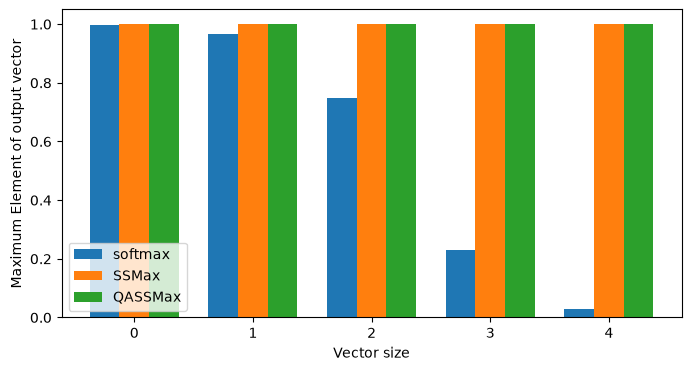

In [ ]:
import matplotlib.pyplot as plt


ssm = SSMax(1)
qassm = QASSMax(1,1).eval()
exponents = [i+1 for i in range(5)]
max_elem_sm = []
max_elem_ssm = []
max_elem_qassm = []
with torch.no_grad():    
    for i in exponents:
        vec = torch.full((10**i,), -3.0)
        vec[-1] = 5 # vec = [-3,-3,-3,...,5]
        
        # standard softmax
        v_sm = F.softmax(vec, dim=-1)

        # scalable softmax
        v_ssm = ssm(vec)

        # query-aware scalable softmax
        q = torch.ones(1,1,1,1)
        k = torch.ones(1,1,10**i,1)

        v_qassm = qassm(q, k, dim=0)

        max_elem_sm.append(v_sm.max())
        max_elem_ssm.append(v_ssm.max())
        max_elem_qassm.append(v_qassm.max())


plt.figure(figsize=(8,4))
x_pos = list(range(5))
width = 0.25
plt.bar([i - width for i in x_pos], max_elem_sm, width=width, label="softmax")
plt.bar(x_pos, max_elem_ssm, width=width, label="SSMax")
plt.bar([i + width for i in x_pos], max_elem_qassm, width=width, label="QASSMax")
plt.xlabel("Vector size")
plt.ylabel("Maximum Element of output vector")
plt.legend(loc="lower left")
plt.show()
"""
In the figure below we can observe that while our dataset [-3,-3,..., 5] changes in size
only the scalable softmax and QASSMax are able to express the last element 5 as having 
"high probability" after the softmax. The normal softmax seems to have too much noise and 
the five virtually disappears as a clear signal with a output value of 0.0289 after the softmax.  
"""

In [63]:
print(max_elem_sm)

[tensor(0.9970), tensor(0.9679), tensor(0.7490), tensor(0.2297), tensor(0.0289)]
